In [9]:
def load_benchmark(benchmark_path):
    with open(benchmark_path) as f:
        numbers = [float(x) for x in f.readlines()[0].split(',')]
        # do we drop the first 5 results while the model was warming up?
        return numbers

In [13]:
import statistics

def get_averages(device):
    device_fp = load_benchmark(f"benchmark_{device}_full")
    device_hp = load_benchmark(f"benchmark_{device}_half")

    return statistics.fmean(device_fp), statistics.fmean(device_hp)

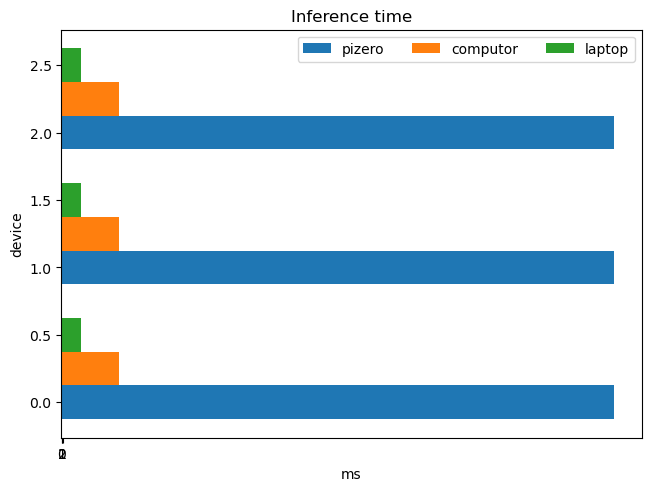

In [22]:
import matplotlib.pyplot as plt
import numpy as np

devices = ['pizero', 'computor', 'laptop'] # 'laptop_weak'

x = np.arange(len(devices))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')
#plt.yscale('log')


for device in devices:
    offset = width * multiplier
    rects = ax.barh(x + offset, get_averages(device)[0], width, label=device)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('device')
ax.set_xlabel('ms')
ax.set_title('Inference time')
ax.set_xticks(x + width, x)
ax.legend(loc='upper right', ncols=3)

plt.show()

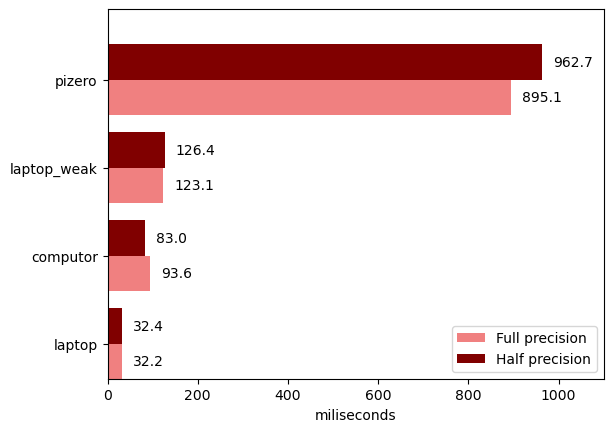

In [51]:
import matplotlib.pyplot as plt
import numpy as np


devices = ['laptop', 'computor', 'laptop_weak', 'pizero']

ind = np.arange(len(devices))
width = 0.4

fp_list = []
hp_list = []
for device in devices:
    res = get_averages(device)
    fp_list.append(res[0])
    hp_list.append(res[1])

#ax.bar_label(hbars, labels=[f'±{e:.2f}' for e in error], padding=8, color='b', fontsize=14)
# ax.bar_label(hbars, fmt='%.2f')
fig, ax = plt.subplots()
hbar1 = ax.barh(ind, fp_list, width, color='lightcoral', label='Full precision')
hbar2 = ax.barh(ind + width, hp_list, width, color='maroon', label='Half precision')
ax.bar_label(hbar1, padding=8, fmt='%.1f')
ax.bar_label(hbar2, padding=8, fmt='%.1f')
ax.set_xlabel('miliseconds')

ax.set(yticks=ind + width/2, yticklabels=devices, ylim=[2*width - 1, len(devices)])
ax.legend()
ax.set_xlim(right=1100)

plt.show()